# Train Overall ResNet50 FCSSAM Notebook

Notebook nay chi dung bo `overall` va chi huan luyen mo hinh `ResNet50 + FCSSAM + Softmax(3)`.

Sau khi train, notebook se:
- danh gia tren `val overall` va `test overall`
- ve history, confusion matrix, ROC va PCA feature space
- phan tich 5 anh test bang CAM, SAMavg, SAMmax, FCSSAM va Grad-CAM

Notebook nay su dung cung bo du lieu va cung pipeline xu ly du lieu voi notebook VGG19 de bao dam viec so sanh khach quan.

Luu y:
- Notebook nay khong tach NIH/external trong bao cao chinh.
- Du lieu train/val/test chi dung bo `overall` da tao truoc do.


In [1]:
import io
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

SEED = 42
AUTOTUNE = tf.data.AUTOTUNE
VALID_IMAGE_EXTS = {".png", ".jpg", ".jpeg"}

CLASS_NAMES = ["normal", "pneumonia_only", "effusion_only"]
CLASS_TO_INDEX = {name: idx for idx, name in enumerate(CLASS_NAMES)}

DATASET_ROOT_CANDIDATES = [
    "/kaggle/input/datasets/thuanminh1310/datasetspbl4/pbl4_main_aux_datasets",
    "/kaggle/working/pbl4_main_aux_datasets",
    "/kaggle/input/pbl4-main-aux-datasets",
]

NIH_IMAGE_ROOT_CANDIDATES = [
    "/kaggle/input/datasets/organizations/nih-chest-xrays/data",
    "/kaggle/input/nih-chest-xrays/data",
    "/kaggle/input/chest-xray14/images",
]

EXTERNAL_ROOT_CANDIDATES = [
    "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray",
    "/kaggle/input/chest-xray-pneumonia/chest_xray",
]

TRAIN_MANIFEST_NAME = "main_train_2_1_1.csv"
VAL_MANIFEST_NAME = "main_val_70_15_15.csv"
TEST_MANIFEST_NAME = "main_test_70_15_15.csv"

RUN_VGG19_BASELINE = False
RUN_RESNET50_FCSSAM = True
DEMO_IMAGE_COUNT = 5

MODEL_CONFIGS = {
    "vgg19": {
        "display_name": "VGG19_GAP_CommonPipelineV2_256_CaffeNoContrast_EffBoost15_AdamW_Smooth",
        "image_size": 256,
        "batch_size": 16,
        "epochs": 15,
        "learning_rate": 1e-4,
        "weight_decay": 1e-4,
        "label_smoothing": 0.03,
        "patience": 4,
        "dropout_rate": 0.30,
        "model_family": "vgg19",
        "effusion_boost": 1.50,
    },
    "resnet50_fcssam": {
        "display_name": "ResNet50_FCSSAM_CommonPipelineV2_256_CaffeNoContrast_EffBoost15_AdamW_Smooth",
        "image_size": 256,
        "batch_size": 16,
        "epochs": 20,
        "learning_rate": 5e-5,
        "weight_decay": 1e-4,
        "label_smoothing": 0.03,
        "patience": 5,
        "keep_ratio": 0.80,
        "attention_ratio": 8,
        "model_family": "resnet50",
        "effusion_boost": 1.50,
    },
}

OUTPUT_DIR = Path("/kaggle/working/train_overall_resnet50_fcssam_common_pipeline_v2_256_caffe_no_contrast_effboost15_adamw_smooth_threshold")
ARTIFACT_DIR = OUTPUT_DIR / "artifacts"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
PREDICTION_DIR = OUTPUT_DIR / "predictions"
for directory in [OUTPUT_DIR, ARTIFACT_DIR, FIGURE_DIR, MODEL_DIR, PREDICTION_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Configuration")
print(f"- classes: {CLASS_NAMES}")
print(f"- train manifest: {TRAIN_MANIFEST_NAME}")
print(f"- val manifest: {VAL_MANIFEST_NAME}")
print(f"- test manifest: {TEST_MANIFEST_NAME}")
print(f"- output dir: {OUTPUT_DIR}")


2026-05-11 14:17:54.552478: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778509074.752362      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778509074.805792      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778509075.258559      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778509075.258595      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778509075.258597      23 computation_placer.cc:177] computation placer alr

Configuration
- classes: ['normal', 'pneumonia_only', 'effusion_only']
- train manifest: main_train_2_1_1.csv
- val manifest: main_val_70_15_15.csv
- test manifest: main_test_70_15_15.csv
- output dir: /kaggle/working/train_overall_resnet50_fcssam_common_pipeline_v2_256_caffe_no_contrast_effboost15_adamw_smooth_threshold


In [2]:
def seed_everything(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def find_existing_dir(candidates):
    for candidate in candidates:
        candidate_path = Path(candidate)
        if candidate_path.exists():
            return candidate_path
    raise FileNotFoundError(f"Could not find any valid directory from: {candidates}")


IMAGE_INDEX_CACHE = {}


def build_image_index(search_root):
    image_map = {}
    duplicate_names = set()
    image_paths = sorted(path for path in search_root.rglob("*") if path.suffix.lower() in VALID_IMAGE_EXTS)
    for image_path in image_paths:
        image_name = image_path.name
        if image_name in image_map and image_map[image_name] != str(image_path):
            duplicate_names.add(image_name)
            continue
        image_map.setdefault(image_name, str(image_path))
    return image_map, duplicate_names


def get_cached_image_index(search_root):
    key = str(search_root)
    if key not in IMAGE_INDEX_CACHE:
        IMAGE_INDEX_CACHE[key] = build_image_index(search_root)
    return IMAGE_INDEX_CACHE[key]


def remap_relative_to_root(original_path, target_root, anchor_name):
    path_obj = Path(str(original_path))
    if path_obj.exists():
        return str(path_obj)
    parts = list(path_obj.parts)
    if anchor_name in parts:
        anchor_idx = parts.index(anchor_name)
        relative_parts = parts[anchor_idx + 1 :]
        candidate = target_root.joinpath(*relative_parts)
        if candidate.exists():
            return str(candidate)
    return str(original_path)


def resolve_manifest_paths(frame, nih_root, external_root):
    df = frame.copy()
    if "resolved_path" not in df.columns:
        raise KeyError("Manifest must contain 'resolved_path'.")

    df["resolved_path"] = df["resolved_path"].astype(str)
    df["resolved_path"] = np.where(
        df["source"].eq("nih"),
        df["resolved_path"].map(lambda p: remap_relative_to_root(p, nih_root, "data")),
        df["resolved_path"],
    )
    df["resolved_path"] = np.where(
        df["source"].eq("chest_xray_pneumonia"),
        df["resolved_path"].map(lambda p: remap_relative_to_root(p, external_root, "chest_xray")),
        df["resolved_path"],
    )

    exists_mask = df["resolved_path"].map(lambda x: Path(str(x)).exists())
    if exists_mask.all():
        df["image_path"] = df["resolved_path"]
        return df

    if df.loc[~exists_mask, "source"].eq("nih").any():
        nih_map, _ = get_cached_image_index(nih_root)
        missing_mask = df["source"].eq("nih") & ~exists_mask
        df.loc[missing_mask, "resolved_path"] = df.loc[missing_mask, "resolved_path"].map(
            lambda p: nih_map.get(Path(str(p)).name, str(p))
        )

    exists_mask = df["resolved_path"].map(lambda x: Path(str(x)).exists())
    if df.loc[~exists_mask, "source"].eq("chest_xray_pneumonia").any():
        ext_map, _ = get_cached_image_index(external_root)
        missing_mask = df["source"].eq("chest_xray_pneumonia") & ~exists_mask
        df.loc[missing_mask, "resolved_path"] = df.loc[missing_mask, "resolved_path"].map(
            lambda p: ext_map.get(Path(str(p)).name, str(p))
        )

    final_missing = ~df["resolved_path"].map(lambda x: Path(str(x)).exists())
    if final_missing.any():
        examples = df.loc[final_missing, ["source", "resolved_path"]].head(5).to_dict("records")
        raise FileNotFoundError(f"Could not resolve some image paths. Examples: {examples}")

    df["image_path"] = df["resolved_path"]
    return df


def load_manifest(manifest_path, class_to_index, nih_root, external_root):
    df = pd.read_csv(manifest_path)
    if "class_index" not in df.columns:
        df["class_index"] = df["class_name"].map(class_to_index)
    if df["class_index"].isna().any():
        bad_classes = sorted(df.loc[df["class_index"].isna(), "class_name"].dropna().unique().tolist())
        raise ValueError(f"Unknown class names found: {bad_classes}")
    df["class_index"] = df["class_index"].astype(int)
    df = resolve_manifest_paths(df, nih_root, external_root)
    return df.reset_index(drop=True)


def summarize_counts(df, class_names, split_name):
    summary_df = df["class_name"].value_counts().reindex(class_names, fill_value=0).rename_axis("class_name").reset_index(name="samples")
    summary_df["split"] = split_name
    return summary_df


def save_model_summary(model_obj, file_path):
    buffer = io.StringIO()
    model_obj.summary(print_fn=lambda x: buffer.write(x + "\n"), line_length=140)
    file_path.write_text(buffer.getvalue(), encoding="utf-8")


seed_everything(SEED)
DATASET_ROOT = find_existing_dir(DATASET_ROOT_CANDIDATES)
MANIFEST_DIR = DATASET_ROOT / "manifests"
NIH_IMAGE_ROOT = find_existing_dir(NIH_IMAGE_ROOT_CANDIDATES)
EXTERNAL_ROOT = find_existing_dir(EXTERNAL_ROOT_CANDIDATES)

print(f"DATASET_ROOT: {DATASET_ROOT}")
print(f"MANIFEST_DIR: {MANIFEST_DIR}")
print(f"NIH_IMAGE_ROOT: {NIH_IMAGE_ROOT}")
print(f"EXTERNAL_ROOT: {EXTERNAL_ROOT}")


DATASET_ROOT: /kaggle/input/datasets/thuanminh1310/datasetspbl4/pbl4_main_aux_datasets
MANIFEST_DIR: /kaggle/input/datasets/thuanminh1310/datasetspbl4/pbl4_main_aux_datasets/manifests
NIH_IMAGE_ROOT: /kaggle/input/datasets/organizations/nih-chest-xrays/data
EXTERNAL_ROOT: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray


In [3]:
train_df = load_manifest(MANIFEST_DIR / TRAIN_MANIFEST_NAME, CLASS_TO_INDEX, NIH_IMAGE_ROOT, EXTERNAL_ROOT)
val_df = load_manifest(MANIFEST_DIR / VAL_MANIFEST_NAME, CLASS_TO_INDEX, NIH_IMAGE_ROOT, EXTERNAL_ROOT)
test_df = load_manifest(MANIFEST_DIR / TEST_MANIFEST_NAME, CLASS_TO_INDEX, NIH_IMAGE_ROOT, EXTERNAL_ROOT)

counts_df = pd.concat([
    summarize_counts(train_df, CLASS_NAMES, "train"),
    summarize_counts(val_df, CLASS_NAMES, "val"),
    summarize_counts(test_df, CLASS_NAMES, "test"),
], ignore_index=True)
counts_df.to_csv(ARTIFACT_DIR / "overall_dataset_counts.csv", index=False)

train_class_counts = train_df["class_index"].value_counts().reindex(range(len(CLASS_NAMES)), fill_value=1).astype(float)
base_class_weights = len(train_df) / (len(CLASS_NAMES) * train_class_counts.values)
base_class_weights = base_class_weights / base_class_weights.mean()
class_weight_df = pd.DataFrame({
    "class_name": CLASS_NAMES,
    "count": train_class_counts.values.astype(int),
    "base_weight": base_class_weights,
})
class_weight_df.to_csv(ARTIFACT_DIR / "base_class_weights.csv", index=False)

display(counts_df)
display(class_weight_df)
display(train_df.head(5))


,class_name,samples,split
0,normal,6190,train
1,pneumonia_only,3095,train
2,effusion_only,3095,train
3,normal,1895,val
4,pneumonia_only,406,val
5,effusion_only,406,val
6,normal,1699,test
7,pneumonia_only,364,test
8,effusion_only,364,test


,class_name,count,base_weight
0,normal,6190,0.6
1,pneumonia_only,3095,1.2
2,effusion_only,3095,1.2


,sample_id,source,original_split,resolved_path,patient_id,patient_group_id,view_position,finding_labels_raw,class_name,selected_clean,split,class_index,image_path
0,nih_00006203_000.png,nih,raw,/kaggle/input/datasets/organizations/nih-chest...,6203,nih_patient_6203,PA,No Finding,normal,True,train,0,/kaggle/input/datasets/organizations/nih-chest...
1,external_train_PNEUMONIA_person796_bacteria_27...,chest_xray_pneumonia,train,/kaggle/input/datasets/paultimothymooney/chest...,person796_bacteria_2702,external_person796,UNK,PNEUMONIA,pneumonia_only,True,train,1,/kaggle/input/datasets/paultimothymooney/chest...
2,nih_00017981_000.png,nih,raw,/kaggle/input/datasets/organizations/nih-chest...,17981,nih_patient_17981,PA,No Finding,normal,True,train,0,/kaggle/input/datasets/organizations/nih-chest...
3,nih_00006738_003.png,nih,raw,/kaggle/input/datasets/organizations/nih-chest...,6738,nih_patient_6738,PA,No Finding,normal,True,train,0,/kaggle/input/datasets/organizations/nih-chest...
4,external_train_PNEUMONIA_person298_bacteria_14...,chest_xray_pneumonia,train,/kaggle/input/datasets/paultimothymooney/chest...,person298_bacteria_1408,external_person298,UNK,PNEUMONIA,pneumonia_only,True,train,1,/kaggle/input/datasets/paultimothymooney/chest...


In [4]:
def build_augmenter():
    return tf.keras.Sequential([
        tf.keras.layers.RandomTranslation(0.015, 0.015),
        tf.keras.layers.RandomZoom(0.03, 0.03),
        tf.keras.layers.RandomFlip("horizontal"),
    ], name="xray_augmenter_v2")


AUGMENTER = build_augmenter()


def enhance_xray_contrast(image):
    """Common X-ray contrast stretch applied before RGB conversion and normalization."""
    image = tf.cast(image, tf.float32)
    image = image / 255.0
    image_min = tf.reduce_min(image, axis=[0, 1, 2], keepdims=True)
    image_max = tf.reduce_max(image, axis=[0, 1, 2], keepdims=True)
    image = (image - image_min) / tf.maximum(image_max - image_min, 1e-6)
    image = tf.image.adjust_gamma(image, gamma=0.95)
    return tf.clip_by_value(image * 255.0, 0.0, 255.0)


def common_preprocess_input(image):
    """Common ImageNet/Caffe-style normalization used by both models."""
    image = tf.cast(image, tf.float32)
    image = image[..., ::-1]  # RGB -> BGR
    mean = tf.constant([103.939, 116.779, 123.680], dtype=tf.float32)
    return image - mean


def get_preprocess_function(model_family):
    # The lecturer requires identical preprocessing for both models.
    # Keep model_family in the signature so the rest of the training code is unchanged.
    return common_preprocess_input


def decode_resize_preprocess(path, label, image_size, preprocess_fn, training=False):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=1, expand_animations=False)
    image.set_shape([None, None, 1])
    image = tf.image.resize(image, [image_size, image_size], method=tf.image.ResizeMethod.BILINEAR)
    image = enhance_xray_contrast(image)
    image = tf.image.grayscale_to_rgb(image)
    if training:
        image = AUGMENTER(image, training=True)
    image = preprocess_fn(image)
    label = tf.cast(label, tf.int32)
    return image, label


def make_dataset(df, image_size, preprocess_fn, batch_size, training=False):
    paths = df["resolved_path"].astype(str).values
    labels = df["class_index"].astype(np.int32).values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda x, y: decode_resize_preprocess(x, y, image_size, preprocess_fn, training=training), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds


I0000 00:00:1778509146.528327      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778509146.534451      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [5]:
layers = tf.keras.layers


@tf.keras.utils.register_keras_serializable()
class ChannelMean(layers.Layer):
    def call(self, inputs):
        return tf.reduce_mean(inputs, axis=-1, keepdims=True)


@tf.keras.utils.register_keras_serializable()
class ChannelMax(layers.Layer):
    def call(self, inputs):
        return tf.reduce_max(inputs, axis=-1, keepdims=True)


@tf.keras.utils.register_keras_serializable()
class FuzzyChannelSelection(layers.Layer):
    def __init__(self, keep_ratio=0.80, **kwargs):
        super().__init__(**kwargs)
        self.keep_ratio = keep_ratio

    def build(self, input_shape):
        channels = int(input_shape[-1])
        self.keep_channels = max(1, int(np.ceil(channels * self.keep_ratio)))
        self.alpha = self.add_weight(
            name="alpha",
            shape=(channels,),
            initializer=tf.keras.initializers.RandomUniform(minval=-0.05, maxval=0.05),
            trainable=True,
        )
        self.richards_A = self.add_weight(
            name="richards_A",
            shape=(),
            initializer=tf.keras.initializers.Constant(0.541324854612918),
            trainable=True,
        )
        self.richards_Q = self.add_weight(
            name="richards_Q",
            shape=(),
            initializer=tf.keras.initializers.Constant(0.541324854612918),
            trainable=True,
        )
        self.richards_mu = self.add_weight(
            name="richards_mu",
            shape=(),
            initializer="zeros",
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs):
        A = tf.nn.softplus(self.richards_A) + 1e-6
        Q = tf.nn.softplus(self.richards_Q) + 1e-6
        scores = 1.0 / (1.0 + tf.exp(A - Q * (self.alpha - self.richards_mu)))
        topk = tf.math.top_k(scores, k=self.keep_channels, sorted=True)
        selected = tf.gather(inputs, topk.indices, axis=-1)
        selected_scores = tf.reshape(topk.values, [1, 1, 1, self.keep_channels])
        return selected * selected_scores

    def get_config(self):
        config = super().get_config()
        config.update({"keep_ratio": self.keep_ratio})
        return config


def create_channel_attention_mask(feature_map, ratio=8, prefix="cam"):
    channels = int(feature_map.shape[-1])
    reduced_channels = max(channels // ratio, 8)

    shared_dense_1 = layers.Dense(reduced_channels, activation="relu", use_bias=False, name=f"{prefix}_dense1")
    shared_dense_2 = layers.Dense(channels, use_bias=False, name=f"{prefix}_dense2")

    avg_pool = layers.GlobalAveragePooling2D(name=f"{prefix}_gap")(feature_map)
    avg_pool = shared_dense_1(avg_pool)
    avg_pool = shared_dense_2(avg_pool)

    max_pool = layers.GlobalMaxPooling2D(name=f"{prefix}_gmp")(feature_map)
    max_pool = shared_dense_1(max_pool)
    max_pool = shared_dense_2(max_pool)

    attention = layers.Add(name=f"{prefix}_add")([avg_pool, max_pool])
    attention = layers.Activation("sigmoid", name=f"{prefix}_sigmoid")(attention)
    attention = layers.Reshape((1, 1, channels), name=f"{prefix}_reshape")(attention)
    return attention


def apply_sc_layers(feature_map, channels, prefix):
    x = layers.SeparableConv2D(channels, 1, padding="same", depthwise_initializer="he_normal", pointwise_initializer="he_normal", name=f"{prefix}_sc1")(feature_map)
    x = layers.SeparableConv2D(channels, 3, padding="same", depthwise_initializer="he_normal", pointwise_initializer="he_normal", name=f"{prefix}_sc2")(x)
    x = layers.BatchNormalization(name=f"{prefix}_bn")(x)
    x = layers.ReLU(name=f"{prefix}_relu")(x)
    return x


def create_spatial_attention_branch(feature_map, cam_mask, pool_mode, prefix):
    channels = int(feature_map.shape[-1])
    sc_features = apply_sc_layers(feature_map, channels, prefix)
    channel_specific = layers.Multiply(name=f"{prefix}_channel_mul")([sc_features, cam_mask])
    if pool_mode == "avg":
        pooled = ChannelMean(name=f"{prefix}_pool")(channel_specific)
    elif pool_mode == "max":
        pooled = ChannelMax(name=f"{prefix}_pool")(channel_specific)
    else:
        raise ValueError(f"Unsupported pool_mode: {pool_mode}")
    spatial_attention = layers.Conv2D(1, 7, padding="same", activation="sigmoid", kernel_initializer="he_normal", name=f"{prefix}_spatial_conv")(pooled)
    branch_output = layers.Multiply(name=f"{prefix}_spatial_mul")([channel_specific, spatial_attention])
    return branch_output


def create_fcssam_module(feature_map, attention_ratio=8, keep_ratio=0.80, prefix="fcssam"):
    cam_mask = create_channel_attention_mask(feature_map, ratio=attention_ratio, prefix=f"{prefix}_cam")
    sam_avg = create_spatial_attention_branch(feature_map, cam_mask, pool_mode="avg", prefix=f"{prefix}_samavg")
    sam_max = create_spatial_attention_branch(feature_map, cam_mask, pool_mode="max", prefix=f"{prefix}_sammax")
    concat_features = layers.Concatenate(name=f"{prefix}_concat")([sam_avg, sam_max])
    selected_features = FuzzyChannelSelection(keep_ratio=keep_ratio, name=f"{prefix}_select")(concat_features)
    return selected_features, {
        "cam_mask_layer": f"{prefix}_cam_reshape",
        "samavg_layer": f"{prefix}_samavg_spatial_mul",
        "sammax_layer": f"{prefix}_sammax_spatial_mul",
        "fcssam_layer": f"{prefix}_select",
    }


def build_vgg19_baseline(input_shape, dropout_rate=0.30):
    inputs = layers.Input(shape=input_shape, name="image")
    backbone = tf.keras.applications.VGG19(include_top=False, weights="imagenet", input_tensor=inputs)
    x = backbone.output
    x = layers.GlobalAveragePooling2D(name="vgg_gap")(x)
    x = layers.Dropout(dropout_rate, name="vgg_dropout")(x)
    x = layers.Dense(256, activation="relu", name="vgg_dense_256")(x)
    x = layers.Dropout(dropout_rate, name="vgg_dropout_2")(x)
    outputs = layers.Dense(len(CLASS_NAMES), activation="softmax", dtype="float32", name="class_probs")(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="vgg19_gap_3class")
    meta = {
        "gradcam_layer": "block5_conv4",
        "feature_layer": "vgg_gap",
    }
    return model, meta


def build_resnet50_fcssam(input_shape, keep_ratio=0.80, attention_ratio=8):
    inputs = layers.Input(shape=input_shape, name="image")
    backbone = tf.keras.applications.ResNet50(include_top=False, weights="imagenet", input_tensor=inputs)
    feature_map = backbone.output
    fcssam_output, attention_meta = create_fcssam_module(feature_map, attention_ratio=attention_ratio, keep_ratio=keep_ratio, prefix="overall_fcssam")
    x = layers.GlobalAveragePooling2D(name="resnet_gap")(fcssam_output)
    outputs = layers.Dense(len(CLASS_NAMES), activation="softmax", dtype="float32", name="class_probs")(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="resnet50_fcssam_3class")
    meta = {
        "gradcam_layer": attention_meta["fcssam_layer"],
        "feature_layer": "resnet_gap",
        "feature_map_layer": "conv5_block3_out",
        "cam_mask_layer": attention_meta["cam_mask_layer"],
        "samavg_layer": attention_meta["samavg_layer"],
        "sammax_layer": attention_meta["sammax_layer"],
        "fcssam_layer": attention_meta["fcssam_layer"],
    }
    return model, meta


In [6]:
def build_weighted_smoothed_sparse_categorical_crossentropy(class_weights, label_smoothing=0.03):
    class_weights_tensor = tf.constant(class_weights, dtype=tf.float32)
    num_classes = len(CLASS_NAMES)

    def loss(y_true, y_pred):
        y_true_int = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.one_hot(y_true_int, depth=num_classes, dtype=tf.float32)
        if label_smoothing > 0:
            smooth_pos = 1.0 - label_smoothing
            smooth_neg = label_smoothing / tf.cast(num_classes - 1, tf.float32)
            y_true_one_hot = y_true_one_hot * smooth_pos + (1.0 - y_true_one_hot) * smooth_neg
        per_example_loss = tf.keras.losses.categorical_crossentropy(y_true_one_hot, y_pred)
        sample_weights = tf.gather(class_weights_tensor, y_true_int)
        return per_example_loss * sample_weights

    return loss


def get_model_class_weights(model_config):
    weights = base_class_weights.copy()
    weights[CLASS_TO_INDEX["effusion_only"]] *= model_config.get("effusion_boost", 1.0)
    weights = weights / weights.mean()
    return weights.astype(np.float32)


def compile_model(model_obj, learning_rate, class_weights, weight_decay=1e-4, label_smoothing=0.03):
    model_obj.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay),
        loss=build_weighted_smoothed_sparse_categorical_crossentropy(class_weights, label_smoothing=label_smoothing),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    )


def build_callbacks(model_key, patience=5):
    model_output_dir = MODEL_DIR / model_key
    model_output_dir.mkdir(parents=True, exist_ok=True)
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(model_output_dir / "best.weights.h5"),
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            save_weights_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.5,
            patience=max(1, patience // 2),
            min_lr=1e-6,
            verbose=1,
        ),
        tf.keras.callbacks.CSVLogger(str(model_output_dir / "history.csv"), append=False),
    ]


def history_to_frame(history, model_key):
    history_df = pd.DataFrame(history.history)
    history_df["epoch"] = np.arange(1, len(history_df) + 1)
    history_df["model_key"] = model_key
    return history_df


def plot_history(history_df, model_key, display_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    best_epoch = int(history_df.loc[history_df["val_loss"].idxmin(), "epoch"])

    axes[0].plot(history_df["epoch"], history_df["loss"], marker="o", label="train_loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")
    axes[0].axvline(best_epoch, linestyle="--", color="gray", alpha=0.6)
    axes[0].set_title(f"{display_name} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history_df["epoch"], history_df["accuracy"], marker="o", label="train_accuracy")
    axes[1].plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="val_accuracy")
    axes[1].axvline(best_epoch, linestyle="--", color="gray", alpha=0.6)
    axes[1].set_title(f"{display_name} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    figure_path = FIGURE_DIR / f"{model_key}_history.png"
    plt.savefig(figure_path, dpi=200, bbox_inches="tight")
    plt.show()
    return figure_path


def predict_dataframe(model_obj, df, image_size, preprocess_fn, batch_size):
    probs = model_obj.predict(make_dataset(df, image_size, preprocess_fn, batch_size, training=False), verbose=1).astype(np.float32)
    y_true = df["class_index"].astype(np.int32).values
    y_pred = probs.argmax(axis=1).astype(np.int32)
    return probs, y_true, y_pred


def compute_per_class_auc(y_true, probs):
    auc_map = {}
    for class_index, class_name in enumerate(CLASS_NAMES):
        binary_true = (y_true == class_index).astype(int)
        if len(np.unique(binary_true)) < 2:
            auc_map[class_name] = np.nan
        else:
            auc_map[class_name] = roc_auc_score(binary_true, probs[:, class_index])
    return auc_map


def evaluate_overall(y_true, probs, y_pred, model_key, split_name):
    report = classification_report(
        y_true,
        y_pred,
        labels=list(range(len(CLASS_NAMES))),
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
    auc_map = compute_per_class_auc(y_true, probs)
    summary_df = pd.DataFrame([{
        "model_key": model_key,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": report["macro avg"]["precision"],
        "macro_recall": report["macro avg"]["recall"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "macro_auc_ovr": float(np.nanmean(list(auc_map.values()))),
    }])
    class_rows = []
    for class_name in CLASS_NAMES:
        class_rows.append({
            "model_key": model_key,
            "split": split_name,
            "class_name": class_name,
            "precision": report[class_name]["precision"],
            "recall": report[class_name]["recall"],
            "f1": report[class_name]["f1-score"],
            "support": int(report[class_name]["support"]),
            "auc_ovr": auc_map[class_name],
        })
    return summary_df, pd.DataFrame(class_rows)



def predict_with_effusion_threshold(probs, threshold):
    effusion_index = CLASS_TO_INDEX["effusion_only"]
    non_effusion_probs = probs.copy()
    non_effusion_probs[:, effusion_index] = -np.inf
    best_non_effusion = np.argmax(non_effusion_probs, axis=1).astype(np.int32)
    return np.where(probs[:, effusion_index] >= threshold, effusion_index, best_non_effusion).astype(np.int32)


def tune_effusion_threshold(y_true, probs, model_key, min_recall=0.75):
    rows = []
    for threshold in np.round(np.arange(0.30, 0.801, 0.01), 2):
        y_pred = predict_with_effusion_threshold(probs, threshold)
        summary_df, class_df = evaluate_overall(y_true, probs, y_pred, model_key, "val_threshold_search")
        effusion_row = class_df.loc[class_df["class_name"] == "effusion_only"].iloc[0]
        summary_row = summary_df.iloc[0]
        rows.append({
            "model_key": model_key,
            "threshold": float(threshold),
            "accuracy": float(summary_row["accuracy"]),
            "macro_f1": float(summary_row["macro_f1"]),
            "macro_precision": float(summary_row["macro_precision"]),
            "macro_recall": float(summary_row["macro_recall"]),
            "effusion_precision": float(effusion_row["precision"]),
            "effusion_recall": float(effusion_row["recall"]),
            "effusion_f1": float(effusion_row["f1"]),
        })
    threshold_df = pd.DataFrame(rows)
    candidates = threshold_df.loc[threshold_df["effusion_recall"] >= min_recall].copy()
    if candidates.empty:
        candidates = threshold_df.copy()
    best_row = candidates.sort_values(
        ["effusion_f1", "macro_f1", "effusion_precision", "accuracy"],
        ascending=[False, False, False, False],
    ).iloc[0]
    return float(best_row["threshold"]), threshold_df

def build_prediction_frame(df, probs, y_pred):
    pred_df = df[["sample_id", "source", "resolved_path", "class_name", "class_index"]].copy()
    pred_df["pred_class_index"] = y_pred
    pred_df["pred_class_name"] = [CLASS_NAMES[idx] for idx in y_pred]
    for idx, class_name in enumerate(CLASS_NAMES):
        pred_df[f"prob_{class_name}"] = probs[:, idx]
    return pred_df


def plot_confusion_matrix_overall(y_true, y_pred, model_key, split_name, display_name):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASS_NAMES))))
    row_sums = np.maximum(cm.sum(axis=1, keepdims=True), 1)
    cm_norm = cm / row_sums
    annotations = np.empty_like(cm, dtype=object)
    for row_idx in range(cm.shape[0]):
        for col_idx in range(cm.shape[1]):
            annotations[row_idx, col_idx] = f"{cm[row_idx, col_idx]}\n{cm_norm[row_idx, col_idx]:.1%}"
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_norm, annot=annotations, fmt="", cmap="Blues", vmin=0.0, vmax=1.0, cbar=False, ax=ax)
    ax.set_title(f"{display_name} | {split_name} overall")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticklabels(CLASS_NAMES, rotation=20)
    ax.set_yticklabels(CLASS_NAMES, rotation=0)
    plt.tight_layout()
    figure_path = FIGURE_DIR / f"{model_key}_{split_name}_overall_confusion.png"
    plt.savefig(figure_path, dpi=200, bbox_inches="tight")
    plt.show()
    return figure_path


def plot_roc_curves(y_true, probs, model_key, display_name, split_name):
    fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(6 * len(CLASS_NAMES), 5))
    if len(CLASS_NAMES) == 1:
        axes = [axes]
    auc_map = compute_per_class_auc(y_true, probs)
    for idx, class_name in enumerate(CLASS_NAMES):
        binary_true = (y_true == idx).astype(int)
        if len(np.unique(binary_true)) < 2:
            axes[idx].axis("off")
            continue
        fpr, tpr, _ = roc_curve(binary_true, probs[:, idx])
        axes[idx].plot(fpr, tpr, label=f"AUC = {auc_map[class_name]:.4f}")
        axes[idx].plot([0, 1], [0, 1], linestyle="--", color="gray")
        axes[idx].set_title(f"{display_name} | {class_name}")
        axes[idx].set_xlabel("False Positive Rate")
        axes[idx].set_ylabel("True Positive Rate")
        axes[idx].legend(loc="lower right")
        axes[idx].grid(alpha=0.3)
    plt.tight_layout()
    figure_path = FIGURE_DIR / f"{model_key}_{split_name}_roc.png"
    plt.savefig(figure_path, dpi=200, bbox_inches="tight")
    plt.show()
    return figure_path


def extract_features(model_obj, df, feature_layer_name, image_size, preprocess_fn, batch_size):
    feature_model = tf.keras.Model(inputs=model_obj.inputs, outputs=model_obj.get_layer(feature_layer_name).output)
    features = feature_model.predict(make_dataset(df, image_size, preprocess_fn, batch_size, training=False), verbose=1)
    if len(features.shape) > 2:
        features = features.reshape(features.shape[0], -1)
    return features


def plot_pca_features(features, y_true, model_key, display_name):
    pca = PCA(n_components=3, random_state=SEED)
    reduced = pca.fit_transform(features)
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    colors = ["#1f77b4", "#d62728", "#2ca02c"]
    for class_index, class_name in enumerate(CLASS_NAMES):
        mask = y_true == class_index
        ax.scatter(reduced[mask, 0], reduced[mask, 1], reduced[mask, 2], s=18, alpha=0.75, label=class_name, color=colors[class_index])
    ax.set_title(f"{display_name} - PCA feature space")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.legend()
    figure_path = FIGURE_DIR / f"{model_key}_pca.png"
    plt.tight_layout()
    plt.savefig(figure_path, dpi=200, bbox_inches="tight")
    plt.show()
    return figure_path


def plot_model_comparison(summary_df):
    test_df_plot = summary_df.loc[summary_df["split"] == "test"].copy()
    plot_df = test_df_plot.melt(id_vars=["model_key", "split"], value_vars=["accuracy", "macro_f1", "macro_auc_ovr"], var_name="metric", value_name="value")
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=plot_df, x="metric", y="value", hue="model_key", ax=ax)
    ax.set_title("Overall test comparison")
    ax.set_ylim(0.0, 1.05)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    figure_path = FIGURE_DIR / "overall_model_comparison.png"
    plt.savefig(figure_path, dpi=200, bbox_inches="tight")
    plt.show()
    return figure_path


In [7]:
def train_one_model(model_key, model_config):
    tf.keras.backend.clear_session()
    seed_everything(SEED)

    image_size = model_config["image_size"]
    batch_size = model_config["batch_size"]
    epochs = model_config["epochs"]
    learning_rate = model_config["learning_rate"]
    weight_decay = model_config.get("weight_decay", 1e-4)
    label_smoothing = model_config.get("label_smoothing", 0.03)
    patience = model_config["patience"]
    display_name = model_config["display_name"]
    model_family = model_config["model_family"]
    preprocess_fn = get_preprocess_function(model_family)
    model_class_weights = get_model_class_weights(model_config)

    train_ds = make_dataset(train_df, image_size, preprocess_fn, batch_size, training=True)
    val_ds = make_dataset(val_df, image_size, preprocess_fn, batch_size, training=False)

    if model_key == "vgg19":
        model_obj, model_meta = build_vgg19_baseline((image_size, image_size, 3), dropout_rate=model_config["dropout_rate"])
    elif model_key == "resnet50_fcssam":
        model_obj, model_meta = build_resnet50_fcssam((image_size, image_size, 3), keep_ratio=model_config["keep_ratio"], attention_ratio=model_config["attention_ratio"])
    else:
        raise ValueError(f"Unsupported model_key: {model_key}")

    compile_model(model_obj, learning_rate=learning_rate, class_weights=model_class_weights, weight_decay=weight_decay, label_smoothing=label_smoothing)

    model_subdir = MODEL_DIR / model_key
    model_subdir.mkdir(parents=True, exist_ok=True)
    save_model_summary(model_obj, model_subdir / "model_summary.txt")
    model_obj.summary(line_length=140)
    print(f"Training {display_name}")
    print(f"- image_size: {image_size}")
    print(f"- batch_size: {batch_size}")
    print(f"- epochs: {epochs}")
    print(f"- learning_rate: {learning_rate}")
    print(f"- weight_decay: {weight_decay}")
    print(f"- label_smoothing: {label_smoothing}")
    print(f"- class_weights: {dict(zip(CLASS_NAMES, model_class_weights.tolist()))}")

    history = model_obj.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=build_callbacks(model_key, patience=patience),
        verbose=1,
    )

    best_weights_path = model_subdir / "best.weights.h5"
    model_obj.load_weights(best_weights_path)
    model_obj.save(model_subdir / "best_model.keras")

    history_df = history_to_frame(history, model_key)
    history_df.to_csv(model_subdir / "history.csv", index=False)
    history_figure = plot_history(history_df, model_key, display_name)

    val_probs, y_val_true, y_val_pred = predict_dataframe(model_obj, val_df, image_size, preprocess_fn, batch_size)
    test_probs, y_test_true, y_test_pred = predict_dataframe(model_obj, test_df, image_size, preprocess_fn, batch_size)

    best_effusion_threshold, threshold_df = tune_effusion_threshold(y_val_true, val_probs, model_key)
    threshold_df.to_csv(ARTIFACT_DIR / f"{model_key}_effusion_threshold_search.csv", index=False)
    print(f"- best_effusion_threshold: {best_effusion_threshold:.2f}")
    display(threshold_df.sort_values(["effusion_f1", "macro_f1"], ascending=False).head(10))

    y_val_pred_tuned = predict_with_effusion_threshold(val_probs, best_effusion_threshold)
    y_test_pred_tuned = predict_with_effusion_threshold(test_probs, best_effusion_threshold)

    val_summary_df, val_class_df = evaluate_overall(y_val_true, val_probs, y_val_pred_tuned, model_key, "val")
    test_summary_df, test_class_df = evaluate_overall(y_test_true, test_probs, y_test_pred_tuned, model_key, "test")
    val_summary_raw_df, val_class_raw_df = evaluate_overall(y_val_true, val_probs, y_val_pred, model_key, "val_raw_argmax")
    test_summary_raw_df, test_class_raw_df = evaluate_overall(y_test_true, test_probs, y_test_pred, model_key, "test_raw_argmax")

    summary_df = pd.concat([val_summary_df, test_summary_df], ignore_index=True)
    class_df = pd.concat([val_class_df, test_class_df], ignore_index=True)
    raw_summary_df = pd.concat([val_summary_raw_df, test_summary_raw_df], ignore_index=True)
    raw_class_df = pd.concat([val_class_raw_df, test_class_raw_df], ignore_index=True)
    summary_df.to_csv(ARTIFACT_DIR / f"{model_key}_summary_metrics.csv", index=False)
    class_df.to_csv(ARTIFACT_DIR / f"{model_key}_class_report.csv", index=False)
    raw_summary_df.to_csv(ARTIFACT_DIR / f"{model_key}_raw_argmax_summary_metrics.csv", index=False)
    raw_class_df.to_csv(ARTIFACT_DIR / f"{model_key}_raw_argmax_class_report.csv", index=False)

    val_pred_df = build_prediction_frame(val_df, val_probs, y_val_pred_tuned)
    test_pred_df = build_prediction_frame(test_df, test_probs, y_test_pred_tuned)
    val_pred_df["raw_pred_class_index"] = y_val_pred
    test_pred_df["raw_pred_class_index"] = y_test_pred
    val_pred_df["raw_pred_class_name"] = [CLASS_NAMES[idx] for idx in y_val_pred]
    test_pred_df["raw_pred_class_name"] = [CLASS_NAMES[idx] for idx in y_test_pred]
    val_pred_df["effusion_threshold"] = best_effusion_threshold
    test_pred_df["effusion_threshold"] = best_effusion_threshold
    val_pred_df.to_csv(PREDICTION_DIR / f"{model_key}_val_predictions.csv", index=False)
    test_pred_df.to_csv(PREDICTION_DIR / f"{model_key}_test_predictions.csv", index=False)

    val_confusion = plot_confusion_matrix_overall(y_val_true, y_val_pred_tuned, model_key, "val", display_name)
    test_confusion = plot_confusion_matrix_overall(y_test_true, y_test_pred_tuned, model_key, "test", display_name)
    val_roc = plot_roc_curves(y_val_true, val_probs, model_key, display_name, "val")
    test_roc = plot_roc_curves(y_test_true, test_probs, model_key, display_name, "test")

    test_features = extract_features(model_obj, test_df, model_meta["feature_layer"], image_size, preprocess_fn, batch_size)
    pca_figure = plot_pca_features(test_features, y_test_true, model_key, display_name)

    return {
        "model": model_obj,
        "model_key": model_key,
        "display_name": display_name,
        "history_df": history_df,
        "summary_df": summary_df,
        "class_df": class_df,
        "val_predictions": val_pred_df,
        "test_predictions": test_pred_df,
        "val_probs": val_probs,
        "test_probs": test_probs,
        "val_true": y_val_true,
        "test_true": y_test_true,
        "val_pred": y_val_pred_tuned,
        "val_pred_raw_argmax": y_val_pred,
        "effusion_threshold": best_effusion_threshold,
        "test_pred": y_test_pred_tuned,
        "test_pred_raw_argmax": y_test_pred,
        "image_size": image_size,
        "batch_size": batch_size,
        "preprocess_fn": preprocess_fn,
        "meta": model_meta,
        "history_figure": history_figure,
        "val_confusion_figure": val_confusion,
        "test_confusion_figure": test_confusion,
        "val_roc_figure": val_roc,
        "test_roc_figure": test_roc,
        "pca_figure": pca_figure,
    }


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "resnet50_fcssam_3class"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━
┃ Layer (type)                            ┃ Output Shape                      ┃               Param # ┃ Connected t
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━
│ image (InputLayer)                      │ (None, 256, 256, 3)               │                     0 │ -          
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ conv1_pad (ZeroPadding2D)               │ (None, 262, 262, 3)               │                     0 │ image[0][0]
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ conv1_conv (Conv2D)                     │ (None, 128, 128, 64)              │                 9,472 │ conv1_pad[0
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ conv1_bn (BatchNormalization)           │ (None, 128, 128, 64)              │                   256 │ conv1_conv[
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ conv1_relu (Activation)                 │ (None, 128, 128, 64)              │                     0 │ conv1_bn[0]
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ pool1_pad (ZeroPadding2D)               │ (None, 130, 130, 64)              │                     0 │ conv1_relu[
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ pool1_pool (MaxPooling2D)               │ (None, 64, 64, 64)                │                     0 │ pool1_pad[0
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ conv2_block1_1_conv (Conv2D)            │ (None, 64, 64, 64)                │                 4,160 │ pool1_pool[
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ conv2_block1_1_bn (BatchNormalization)  │ (None, 64, 64, 64)                │                   256 │ conv2_block
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ conv2_block1_1_relu (Activation)        │ (None, 64, 64, 64)                │                     0 │ conv2_block
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ conv2_block1_2_conv (Conv2D)            │ (None, 64, 64, 64)                │                36,928 │ conv2_block
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ conv2_block1_2_bn (BatchNormalization)  │ (None, 64, 64, 64)                │                   256 │ conv2_block
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ conv2_block1_2_relu (Activation)        │ (None, 64, 64, 64)                │                     0 │ conv2_block
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ conv2_block1_0_conv (Conv2D)            │ (None, 64, 64, 256)               │                16,640 │ pool1_pool[
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ conv2_block1_3_conv (Conv2D)            │ (None, 64, 64, 256)               │                16,640 │ conv2_block
├─────────────────────────────────────────┼───────────────────────────────────┼───────────────────────┼────────────
│ conv2_block1_0_bn (BatchNormalization)  │ (None, 64, 64, 256)               │                 1,024 │ conv2_block
├─────────────────────────────────────────┼─────────────

 Total params: 41,493,073 (158.28 MB)

 Trainable params: 41,431,761 (158.05 MB)

...

773/774 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.4014 - loss: 0.8003

2026-05-11 14:25:34.138446: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 14:25:34.304727: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 14:25:37.082748: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 14:25:37.232381: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


774/774 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.4016 - loss: 0.8000

2026-05-11 14:26:23.572068: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 14:26:23.736908: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_loss improved from inf to 0.42131, saving model to /kaggle/working/train_overall_resnet50_fcssam_common_pipeline_v2_256_caffe_no_contrast_effboost15_adamw_smooth_threshold/models/resnet50_fcssam/best.weights.h5
774/774 ━━━━━━━━━━━━━━━━━━━━ 435s 475ms/step - accuracy: 0.4018 - loss: 0.7998 - val_accuracy: 0.7133 - val_loss: 0.4213 - learning_rate: 5.0000e-05
Epoch 2/20
774/774 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.8419 - loss: 0.3868
Epoch 2: val_loss improved from 0.42131 to 0.38814, saving model to /kaggle/working/train_overall_resnet50_fcssam_common_pipeline_v2_256_caffe_no_contrast_effboost15_adamw_smooth_threshold/models/resnet50_fcssam/best.weights.h5
774/774 ━━━━━━━━━━━━━━━━━━━━ 308s 398ms/step - accuracy: 0.8419 - loss: 0.3868 - val_accuracy: 0.7566 - val_loss: 0.3881 - learning_rate: 5.0000e-05
Epoch 3/20
774/774 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.8617 - loss: 0.3426
Epoch 3: val_loss did not improve from 0.38814
774/774 ━━━━━━━━━━━━━━━━━━

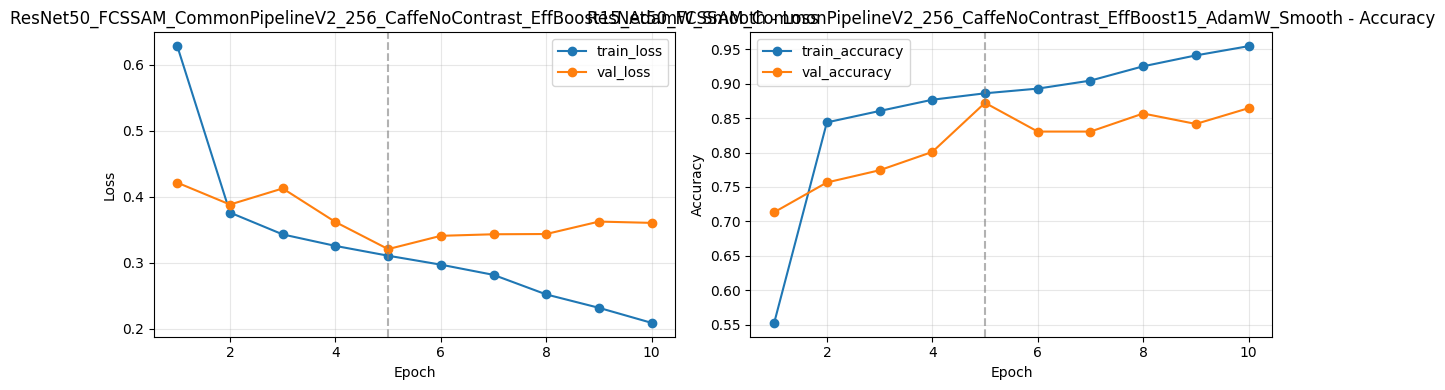

170/170 ━━━━━━━━━━━━━━━━━━━━ 26s 128ms/step
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step

2026-05-11 15:13:31.262043: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 15:13:31.427105: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


152/152 ━━━━━━━━━━━━━━━━━━━━ 24s 155ms/step
- best_effusion_threshold: 0.44


,model_key,threshold,accuracy,macro_f1,macro_precision,macro_recall,effusion_precision,effusion_recall,effusion_f1
25,resnet50_fcssam,0.55,0.881788,0.847737,0.842185,0.855331,0.623377,0.709360,0.663594
23,resnet50_fcssam,0.53,0.879941,0.846954,0.839856,0.857032,0.614737,0.719212,0.662883
24,resnet50_fcssam,0.54,0.880680,0.846928,0.840788,0.855448,0.618844,0.711823,0.662085
26,resnet50_fcssam,0.56,0.881788,0.847248,0.842238,0.854040,0.624454,0.704433,0.662037
27,resnet50_fcssam,0.57,0.882896,0.847567,0.843767,0.852633,0.630290,0.697044,0.661988
22,resnet50_fcssam,0.52,0.878094,0.845700,0.837669,0.857442,0.607438,0.724138,0.660674
21,resnet50_fcssam,0.51,0.876986,0.844906,0.836398,0.857560,0.603272,0.726601,0.659218
20,resnet50_fcssam,0.50,0.875508,0.844247,0.834793,0.858791,0.597194,0.733990,0.658564
30,resnet50_fcssam,0.60,0.883635,0.846508,0.845115,0.848469,0.637413,0.679803,0.657926
31,resnet50_fcssam,0.61,0.884743,0.846808,0.846863,0.847061,0.643868,0.672414,0.657831


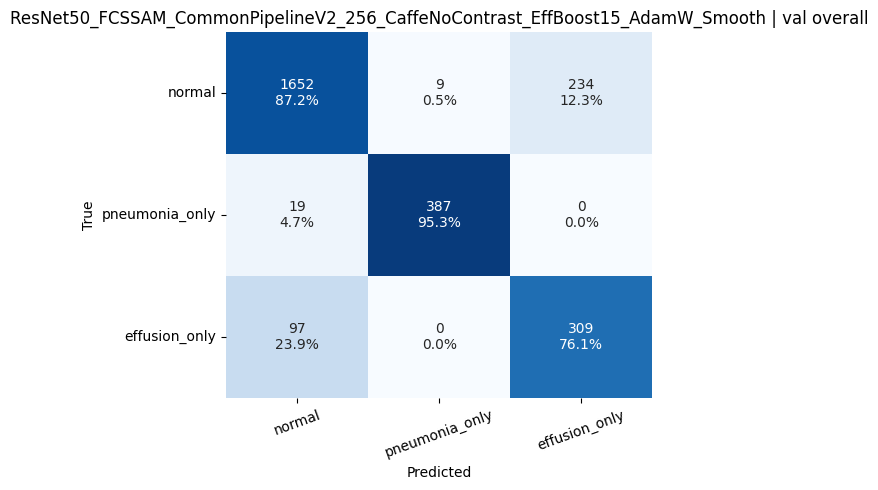

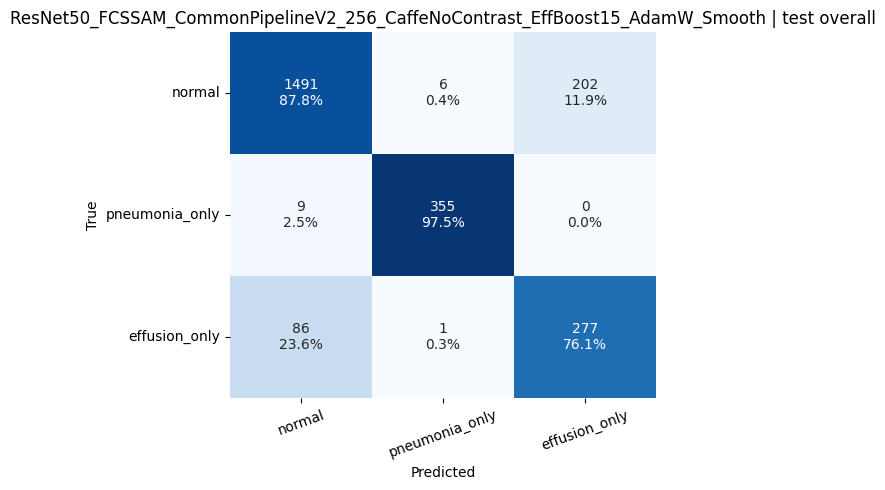

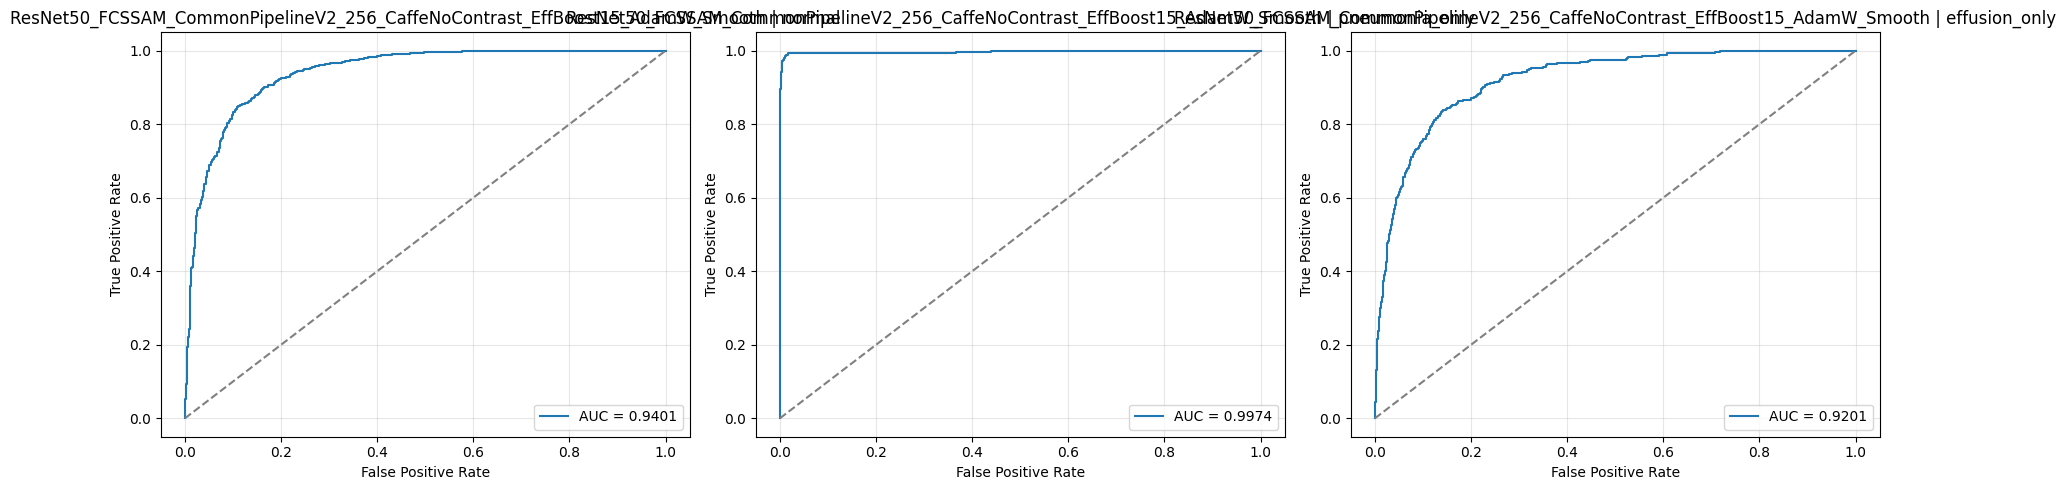

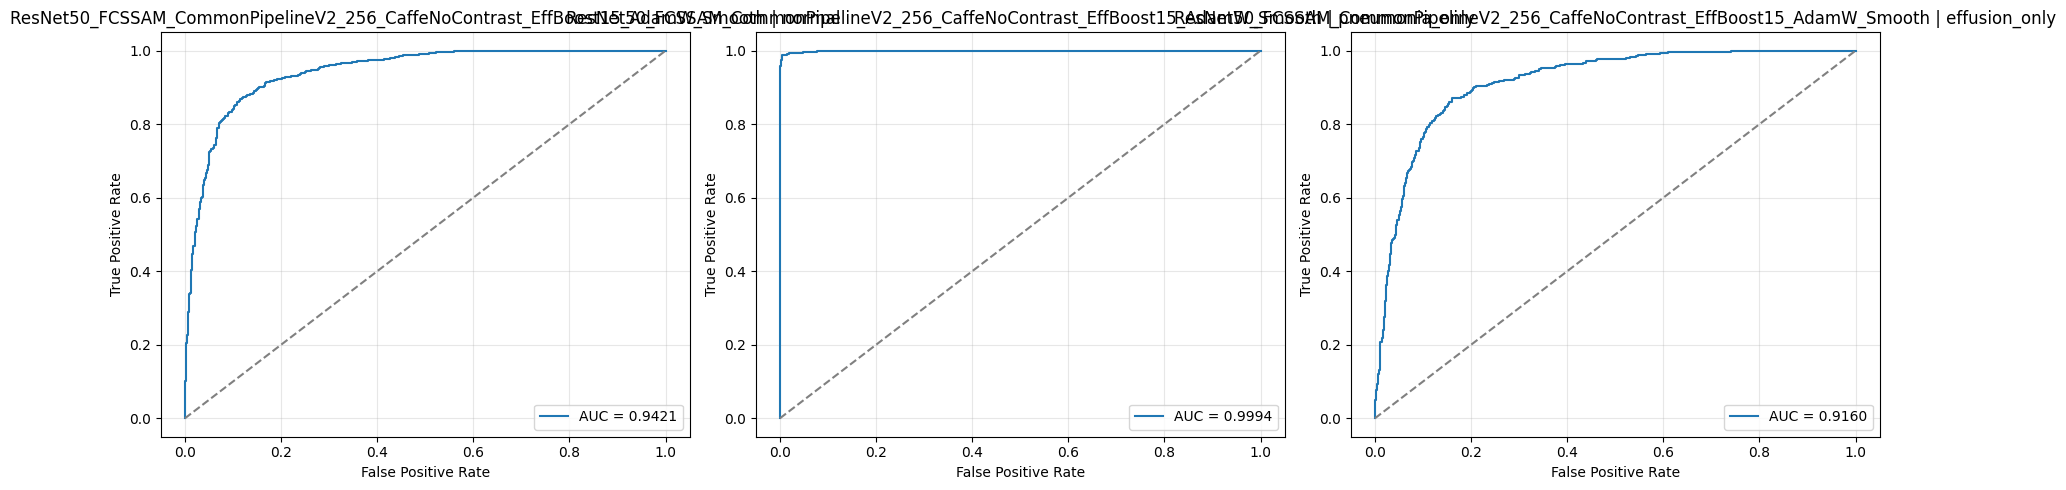

152/152 ━━━━━━━━━━━━━━━━━━━━ 24s 131ms/step


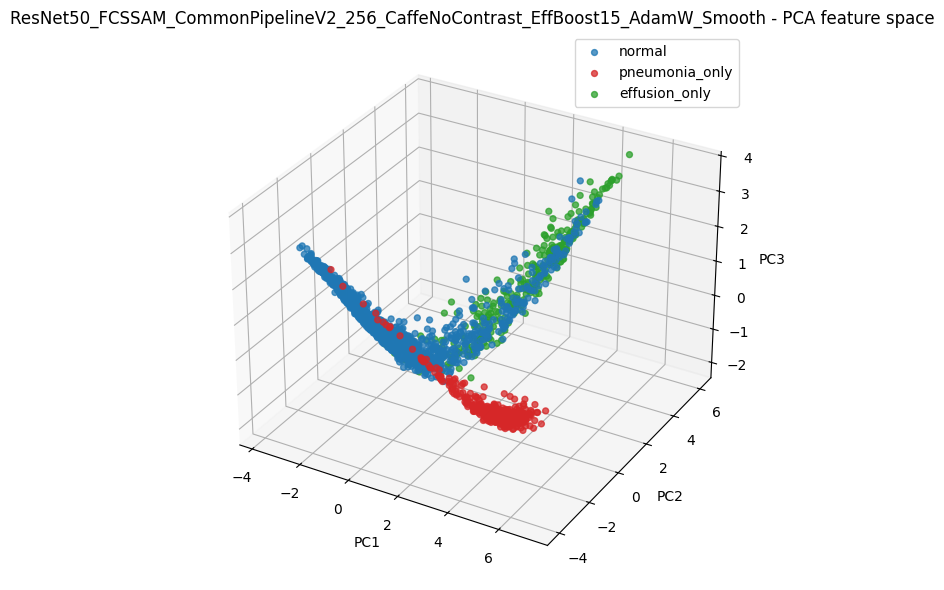

,model_key,split,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_auc_ovr
0,resnet50_fcssam,val,0.867381,0.826908,0.862018,0.839431,0.873843,0.952518
1,resnet50_fcssam,test,0.874742,0.833017,0.871280,0.847634,0.880708,0.952491


,model_key,split,class_name,precision,recall,f1,support,auc_ovr
0,resnet50_fcssam,val,normal,0.934389,0.871768,0.901993,1895,0.940107
1,resnet50_fcssam,val,pneumonia_only,0.977273,0.953202,0.965087,406,0.997387
2,resnet50_fcssam,val,effusion_only,0.569061,0.761084,0.651212,406,0.920060
3,resnet50_fcssam,test,normal,0.940101,0.877575,0.907763,1699,0.942081
4,resnet50_fcssam,test,pneumonia_only,0.980663,0.975275,0.977961,364,0.999375
5,resnet50_fcssam,test,effusion_only,0.578288,0.760989,0.657177,364,0.916016


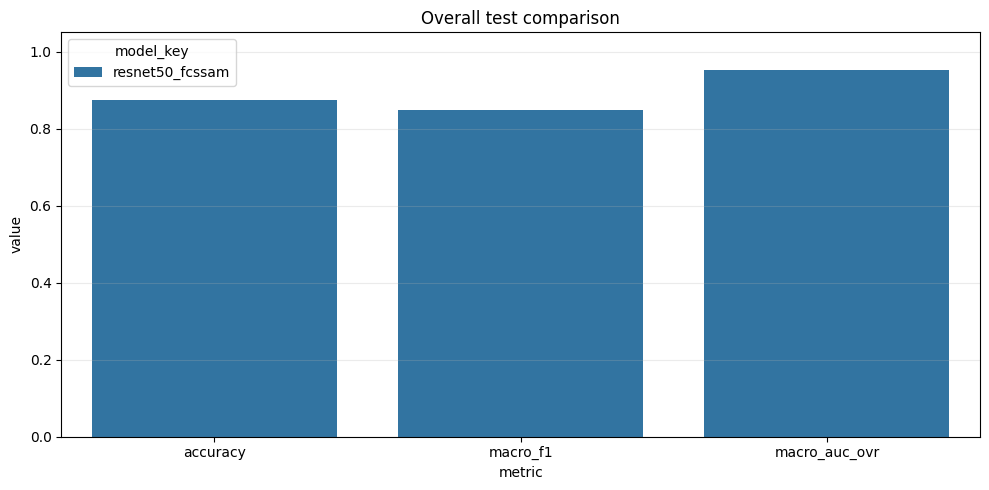

PosixPath('/kaggle/working/train_overall_resnet50_fcssam_common_pipeline_v2_256_caffe_no_contrast_effboost15_adamw_smooth_threshold/figures/overall_model_comparison.png')

In [8]:
results = {}

if RUN_VGG19_BASELINE:
    results["vgg19"] = train_one_model("vgg19", MODEL_CONFIGS["vgg19"])

if RUN_RESNET50_FCSSAM:
    results["resnet50_fcssam"] = train_one_model("resnet50_fcssam", MODEL_CONFIGS["resnet50_fcssam"])

comparison_summary_df = pd.concat([result["summary_df"] for result in results.values()], ignore_index=True)
comparison_class_df = pd.concat([result["class_df"] for result in results.values()], ignore_index=True)

if "vgg19" in results and "resnet50_fcssam" in results:
    ensemble_val_probs = (results["vgg19"]["val_probs"] + results["resnet50_fcssam"]["val_probs"]) / 2.0
    ensemble_test_probs = (results["vgg19"]["test_probs"] + results["resnet50_fcssam"]["test_probs"]) / 2.0
    ensemble_val_pred = ensemble_val_probs.argmax(axis=1).astype(np.int32)
    ensemble_test_pred = ensemble_test_probs.argmax(axis=1).astype(np.int32)

    ensemble_val_summary_df, ensemble_val_class_df = evaluate_overall(results["vgg19"]["val_true"], ensemble_val_probs, ensemble_val_pred, "ensemble_avg", "val")
    ensemble_test_summary_df, ensemble_test_class_df = evaluate_overall(results["vgg19"]["test_true"], ensemble_test_probs, ensemble_test_pred, "ensemble_avg", "test")
    comparison_summary_df = pd.concat([comparison_summary_df, ensemble_val_summary_df, ensemble_test_summary_df], ignore_index=True)
    comparison_class_df = pd.concat([comparison_class_df, ensemble_val_class_df, ensemble_test_class_df], ignore_index=True)

comparison_summary_df.to_csv(ARTIFACT_DIR / "model_comparison_summary.csv", index=False)
comparison_class_df.to_csv(ARTIFACT_DIR / "model_comparison_class_report.csv", index=False)

display(comparison_summary_df)
display(comparison_class_df)
plot_model_comparison(comparison_summary_df)


In [9]:
def load_single_image(image_path, image_size, preprocess_fn):
    image_bytes = tf.io.read_file(image_path)
    image = tf.io.decode_image(image_bytes, channels=1, expand_animations=False)
    image.set_shape([None, None, 1])
    image = tf.image.resize(image, [image_size, image_size])
    image = tf.cast(image, tf.float32)
    image_rgb = tf.image.grayscale_to_rgb(image)
    image_preprocessed = preprocess_fn(image_rgb)
    return image_rgb, tf.expand_dims(image_preprocessed, axis=0)


def activation_to_heatmap(activation):
    arr = np.array(activation)
    if arr.ndim == 4:
        arr = arr[0]
    if arr.ndim == 3:
        arr = arr.mean(axis=-1)
    arr = np.maximum(arr, 0)
    arr = arr - arr.min()
    max_value = arr.max()
    if max_value > 0:
        arr = arr / max_value
    return arr


def resize_heatmap(heatmap, image_size):
    return tf.image.resize(heatmap[..., np.newaxis], [image_size, image_size]).numpy().squeeze()


def overlay_heatmap(image_rgb, heatmap_resized, alpha=0.35):
    image_np = tf.clip_by_value(image_rgb / 255.0, 0.0, 1.0).numpy()
    colored_heatmap = plt.get_cmap("jet")(heatmap_resized)[..., :3]
    overlay = np.clip((1 - alpha) * image_np + alpha * colored_heatmap, 0.0, 1.0)
    return overlay


def make_gradcam_heatmap(model_obj, image_tensor, class_index, layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model_obj.inputs,
        outputs=[model_obj.get_layer(layer_name).output, model_obj.output],
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image_tensor, training=False)
        target_score = predictions[:, class_index]
    grads = tape.gradient(target_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def choose_demo_rows(df, total_count=5):
    desired_sequence = ["normal", "pneumonia_only", "effusion_only", "normal", "pneumonia_only"]
    rows = []
    used_indices = set()
    for class_name in desired_sequence:
        class_candidates = df.loc[df["class_name"] == class_name]
        for idx, row in class_candidates.iterrows():
            if idx not in used_indices:
                rows.append(row)
                used_indices.add(idx)
                break
    if len(rows) < total_count:
        for idx, row in df.iterrows():
            if idx not in used_indices:
                rows.append(row)
                used_indices.add(idx)
            if len(rows) == total_count:
                break
    return pd.DataFrame(rows).reset_index(drop=True)


,sample_id,class_name,source,resolved_path
0,nih_00013616_003.png,normal,nih,/kaggle/input/datasets/organizations/nih-chest...
1,external_train_PNEUMONIA_person761_bacteria_26...,pneumonia_only,chest_xray_pneumonia,/kaggle/input/datasets/paultimothymooney/chest...
2,nih_00013285_016.png,effusion_only,nih,/kaggle/input/datasets/organizations/nih-chest...
3,nih_00010505_007.png,normal,nih,/kaggle/input/datasets/organizations/nih-chest...
4,external_test_PNEUMONIA_person119_bacteria_565...,pneumonia_only,chest_xray_pneumonia,/kaggle/input/datasets/paultimothymooney/chest...


2026-05-11 15:14:08.610054: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 15:14:08.762998: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


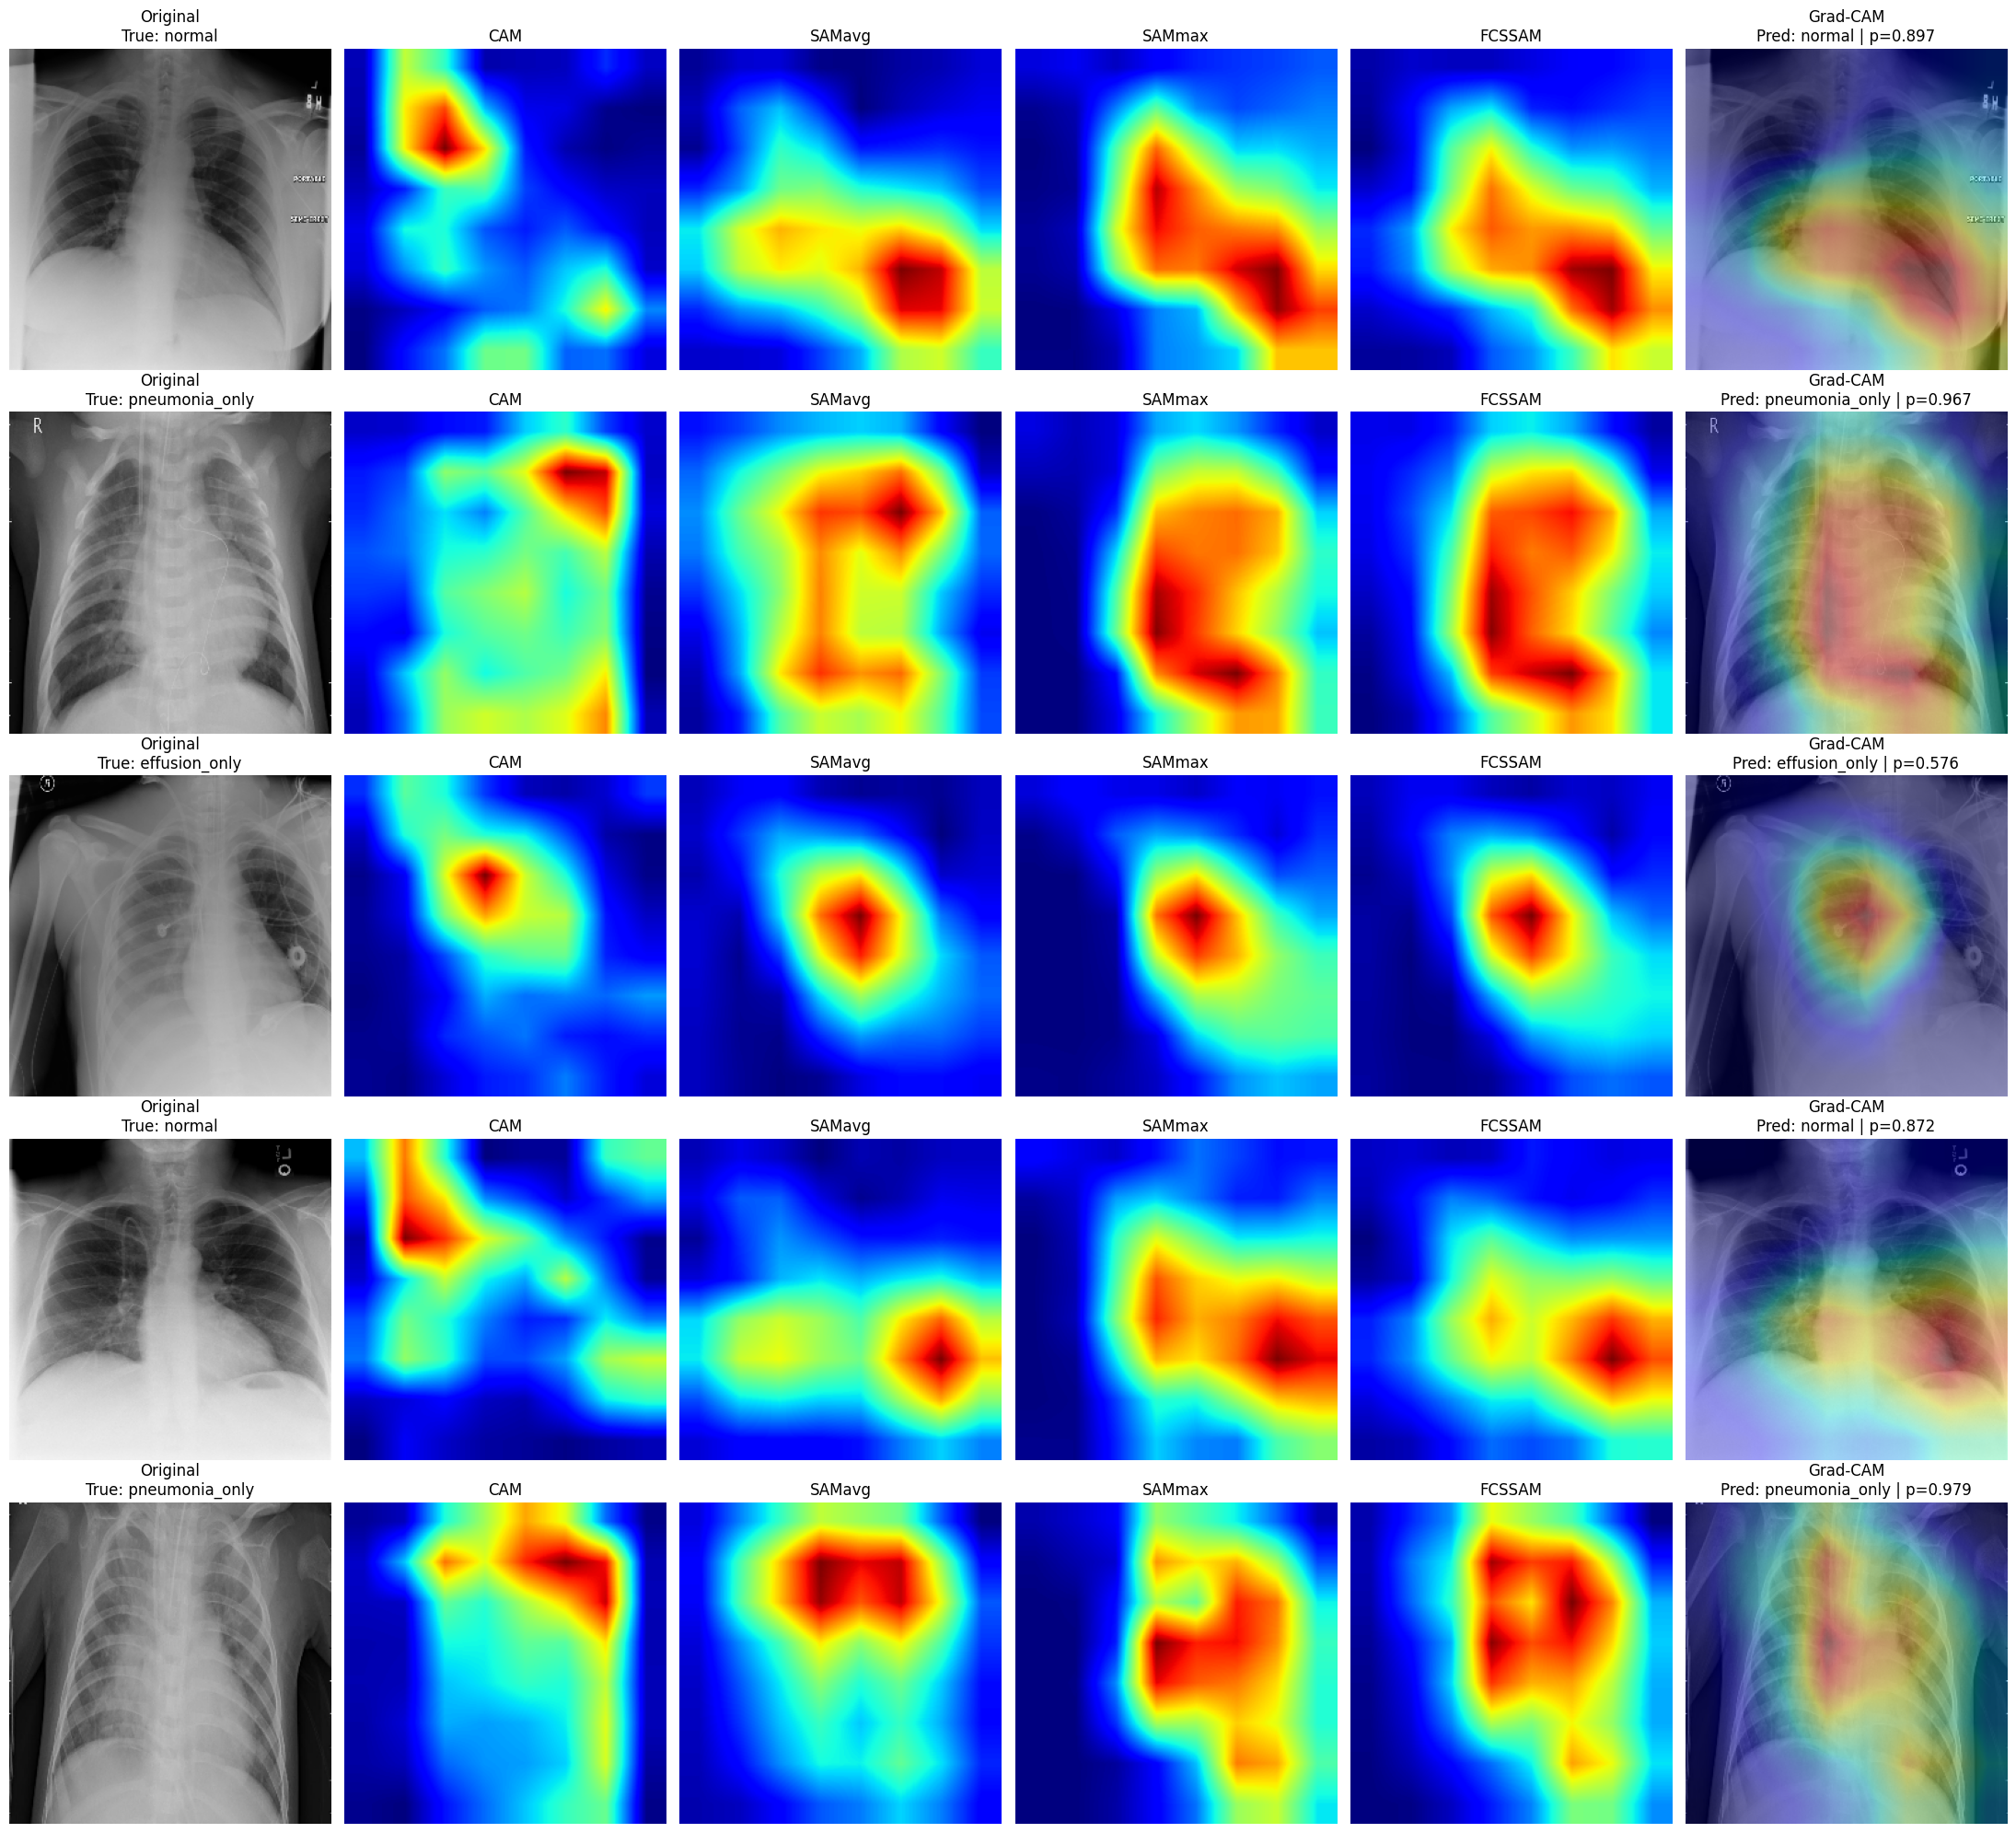

Saved: /kaggle/working/train_overall_resnet50_fcssam_common_pipeline_v2_256_caffe_no_contrast_effboost15_adamw_smooth_threshold/figures/resnet50_fcssam_test5_attention_gradcam.png


In [10]:
demo_rows_df = choose_demo_rows(test_df, total_count=DEMO_IMAGE_COUNT)
display(demo_rows_df[["sample_id", "class_name", "source", "resolved_path"]])

if "vgg19" in results:
    vgg_result = results["vgg19"]
    fig, axes = plt.subplots(len(demo_rows_df), 3, figsize=(12, 4 * len(demo_rows_df)))
    if len(demo_rows_df) == 1:
        axes = np.expand_dims(axes, axis=0)
    for row_idx, sample_row in demo_rows_df.iterrows():
        image_rgb, input_tensor = load_single_image(sample_row["resolved_path"], vgg_result["image_size"], vgg_result["preprocess_fn"])
        probs = vgg_result["model"].predict(input_tensor, verbose=0)[0]
        pred_index = int(np.argmax(probs))
        gradcam = make_gradcam_heatmap(vgg_result["model"], input_tensor, pred_index, vgg_result["meta"]["gradcam_layer"])
        gradcam_resized = resize_heatmap(gradcam, vgg_result["image_size"])
        overlay = overlay_heatmap(image_rgb, gradcam_resized)

        axes[row_idx, 0].imshow(tf.cast(image_rgb, tf.uint8).numpy().squeeze(), cmap="gray")
        axes[row_idx, 0].set_title(f"True: {sample_row['class_name']}")
        axes[row_idx, 0].axis("off")

        axes[row_idx, 1].imshow(gradcam_resized, cmap="jet")
        axes[row_idx, 1].set_title(f"Pred: {CLASS_NAMES[pred_index]}")
        axes[row_idx, 1].axis("off")

        axes[row_idx, 2].imshow(overlay)
        axes[row_idx, 2].set_title(f"Grad-CAM | p={probs[pred_index]:.3f}")
        axes[row_idx, 2].axis("off")

    plt.tight_layout()
    vgg_demo_path = FIGURE_DIR / "vgg19_test5_gradcam.png"
    plt.savefig(vgg_demo_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {vgg_demo_path}")

if "resnet50_fcssam" in results:
    resnet_result = results["resnet50_fcssam"]
    probe_model = tf.keras.Model(
        inputs=resnet_result["model"].inputs,
        outputs=[
            resnet_result["model"].get_layer(resnet_result["meta"]["feature_map_layer"]).output,
            resnet_result["model"].get_layer(resnet_result["meta"]["cam_mask_layer"]).output,
            resnet_result["model"].get_layer(resnet_result["meta"]["samavg_layer"]).output,
            resnet_result["model"].get_layer(resnet_result["meta"]["sammax_layer"]).output,
            resnet_result["model"].get_layer(resnet_result["meta"]["fcssam_layer"]).output,
            resnet_result["model"].output,
        ],
    )

    fig, axes = plt.subplots(len(demo_rows_df), 6, figsize=(22, 4 * len(demo_rows_df)))
    if len(demo_rows_df) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, sample_row in demo_rows_df.iterrows():
        image_rgb, input_tensor = load_single_image(sample_row["resolved_path"], resnet_result["image_size"], resnet_result["preprocess_fn"])
        feature_map_act, cam_mask_act, samavg_act, sammax_act, fcssam_act, probs_tensor = probe_model.predict(input_tensor, verbose=0)
        probs = probs_tensor[0]
        pred_index = int(np.argmax(probs))

        cam_combined = feature_map_act[0] * cam_mask_act[0]
        cam_heatmap = resize_heatmap(activation_to_heatmap(cam_combined), resnet_result["image_size"])
        samavg_heatmap = resize_heatmap(activation_to_heatmap(samavg_act), resnet_result["image_size"])
        sammax_heatmap = resize_heatmap(activation_to_heatmap(sammax_act), resnet_result["image_size"])
        fcssam_heatmap = resize_heatmap(activation_to_heatmap(fcssam_act), resnet_result["image_size"])
        gradcam = make_gradcam_heatmap(resnet_result["model"], input_tensor, pred_index, resnet_result["meta"]["gradcam_layer"])
        gradcam_heatmap = resize_heatmap(gradcam, resnet_result["image_size"])
        gradcam_overlay = overlay_heatmap(image_rgb, gradcam_heatmap)

        axes[row_idx, 0].imshow(tf.cast(image_rgb, tf.uint8).numpy().squeeze(), cmap="gray")
        axes[row_idx, 0].set_title(f"Original\nTrue: {sample_row['class_name']}")
        axes[row_idx, 0].axis("off")

        axes[row_idx, 1].imshow(cam_heatmap, cmap="jet")
        axes[row_idx, 1].set_title("CAM")
        axes[row_idx, 1].axis("off")

        axes[row_idx, 2].imshow(samavg_heatmap, cmap="jet")
        axes[row_idx, 2].set_title("SAMavg")
        axes[row_idx, 2].axis("off")

        axes[row_idx, 3].imshow(sammax_heatmap, cmap="jet")
        axes[row_idx, 3].set_title("SAMmax")
        axes[row_idx, 3].axis("off")

        axes[row_idx, 4].imshow(fcssam_heatmap, cmap="jet")
        axes[row_idx, 4].set_title("FCSSAM")
        axes[row_idx, 4].axis("off")

        axes[row_idx, 5].imshow(gradcam_overlay)
        axes[row_idx, 5].set_title(f"Grad-CAM\nPred: {CLASS_NAMES[pred_index]} | p={probs[pred_index]:.3f}")
        axes[row_idx, 5].axis("off")

    plt.tight_layout()
    resnet_demo_path = FIGURE_DIR / "resnet50_fcssam_test5_attention_gradcam.png"
    plt.savefig(resnet_demo_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {resnet_demo_path}")


In [11]:
print("Saved outputs")
print(f"- counts: {ARTIFACT_DIR / 'overall_dataset_counts.csv'}")
print(f"- model comparison summary: {ARTIFACT_DIR / 'model_comparison_summary.csv'}")
print(f"- model comparison class report: {ARTIFACT_DIR / 'model_comparison_class_report.csv'}")
print(f"- model comparison figure: {FIGURE_DIR / 'overall_model_comparison.png'}")
for model_key, result in results.items():
    print(f"--- {model_key} ---")
    print(f"history figure: {result['history_figure']}")
    print(f"val confusion: {result['val_confusion_figure']}")
    print(f"test confusion: {result['test_confusion_figure']}")
    print(f"val roc: {result['val_roc_figure']}")
    print(f"test roc: {result['test_roc_figure']}")
    print(f"pca figure: {result['pca_figure']}")
    print(f"model dir: {MODEL_DIR / model_key}")
    print(f"val predictions: {PREDICTION_DIR / f'{model_key}_val_predictions.csv'}")
    print(f"test predictions: {PREDICTION_DIR / f'{model_key}_test_predictions.csv'}")


Saved outputs
- counts: /kaggle/working/train_overall_resnet50_fcssam_common_pipeline_v2_256_caffe_no_contrast_effboost15_adamw_smooth_threshold/artifacts/overall_dataset_counts.csv
- model comparison summary: /kaggle/working/train_overall_resnet50_fcssam_common_pipeline_v2_256_caffe_no_contrast_effboost15_adamw_smooth_threshold/artifacts/model_comparison_summary.csv
- model comparison class report: /kaggle/working/train_overall_resnet50_fcssam_common_pipeline_v2_256_caffe_no_contrast_effboost15_adamw_smooth_threshold/artifacts/model_comparison_class_report.csv
- model comparison figure: /kaggle/working/train_overall_resnet50_fcssam_common_pipeline_v2_256_caffe_no_contrast_effboost15_adamw_smooth_threshold/figures/overall_model_comparison.png
--- resnet50_fcssam ---
history figure: /kaggle/working/train_overall_resnet50_fcssam_common_pipeline_v2_256_caffe_no_contrast_effboost15_adamw_smooth_threshold/figures/resnet50_fcssam_history.png
val confusion: /kaggle/working/train_overall_resne